## Project Overview


## Cargar datos fMRI e importación de librerías

Se carga la imagen fMRI (4D: dimensiones espaciales + tiempo). A diferencia del Notebook1, no se usa get_fdata() para evitar saturar la RAM.

In [ ]:
import pickle

# Cargar time_series
with open('time_series.pkl', 'rb') as f:
    time_series = pickle.load(f)

# Cargar mask_imgs_resampled (si lo guardaste)
with open('mask_imgs_resampled.pkl', 'rb') as f:
    mask_imgs_resampled = pickle.load(f)

print("Variables cargadas correctamente")
print("Shape time_series:", time_series.shape)  # debería ser (256, 7)

In [8]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from nilearn import datasets
from nilearn.image import resample_to_img, load_img
from nilearn.maskers import NiftiLabelsMasker, NiftiMasker
from nilearn import plotting
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

In [9]:
img = nib.load("../data/raw/sub--011/func/sub-011_task-rest_run-01_bold.nii.gz")

print("Dimensiones fMRI:", img.shape)

Dimensiones fMRI: (186, 186, 123, 256)


## Cargar atlas Schaefer (original, MNI152)

Se carga el atlas de Schaefer con 100 regiones parceladas según las 7 redes de Yeo. El atlas está en espacio MNI152, mientras que nuestros datos están en MNI305. En lugar de resamplear las 100 ROIs (que provocaba pérdida de regiones), vamos a agrupar primero las ROIs por red y resamplear solo las 7 máscaras resultantes.

In [10]:
atlas = datasets.fetch_atlas_schaefer_2018(n_rois=100, yeo_networks=7)
atlas_img = nib.load(atlas.maps)
print("Atlas Schaefer cargado (MNI152)")

[fetch_atlas_schaefer_2018] Dataset found in C:\Users\Usuario\nilearn_data\schaefer_2018

Atlas Schaefer cargado (MNI152)


## Construir máscaras binarias para las 7 RSNs (en MNI152)

El atlas contiene una imagen (atlas_img) donde cada voxel tiene un número de ROI (1..100). Además, la propiedad atlas.labels indica a qué red de Yeo pertenece cada ROI. Creamos una máscara por red: 1 si el voxel pertenece a alguna ROI de esa red, 0 en caso contrario.

In [11]:
# Obtener los datos del atlas (asumiendo que 'atlas_img' ya está cargado)
atlas_data = atlas_img.get_fdata().astype(int)

# Mapeo de nombre de red a número
net_name_to_number = {
    'Vis': 1,
    'SomMot': 2,
    'DorsAttn': 3,
    'SalVentAttn': 4,
    'Limbic': 5,
    'Cont': 6,
    'Default': 7
}

all_labels = atlas.labels
roi_to_network = {}

for i, label in enumerate(all_labels[1:], start=1):
    parts = label.split('_')
    net_name = None
    for part in parts:
        if part in net_name_to_number:
            net_name = part
            break
    if net_name is not None:
        roi_to_network[i] = net_name_to_number[net_name]

# Inicializar máscaras (7 imágenes 3D)
mask_3d_shape = atlas_data.shape
masks = {net: np.zeros(mask_3d_shape, dtype=np.uint8) for net in range(1, 8)}

# Asignar voxeles a cada red
for roi, net in roi_to_network.items():
    masks[net][atlas_data == roi] = 1

# Convertir a imágenes Nifti (en MNI152)
from nibabel import Nifti1Image
mask_imgs = {net: Nifti1Image(masks[net], affine=atlas_img.affine) for net in range(1,8)}

In [12]:
# Invertir el diccionario para obtener el nombre a partir del número
number_to_name = {v: k for k, v in net_name_to_number.items()}

# Verificar todas las redes
for net in range(1, 8):
    total_voxels = np.sum(masks[net])
    print(f"Red {net} ({number_to_name[net]}): {total_voxels} vóxeles activos")

Red 1 (Vis): 181777 vóxeles activos
Red 2 (SomMot): 128983 vóxeles activos
Red 3 (DorsAttn): 159456 vóxeles activos
Red 4 (SalVentAttn): 108704 vóxeles activos
Red 5 (Limbic): 92104 vóxeles activos
Red 6 (Cont): 123444 vóxeles activos
Red 7 (Default): 261217 vóxeles activos


## Plot de las redes y visualización de ellas mediante gráficas

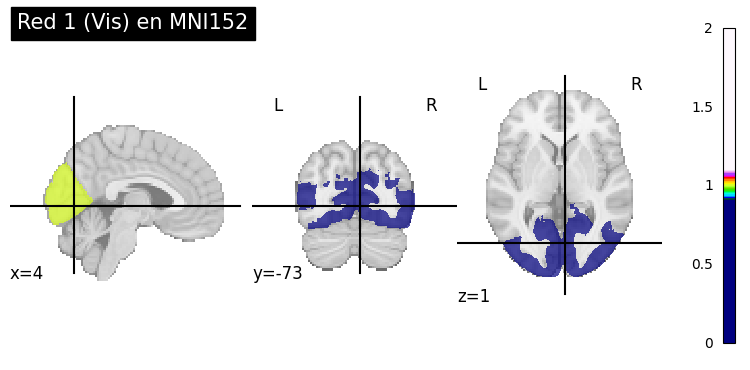

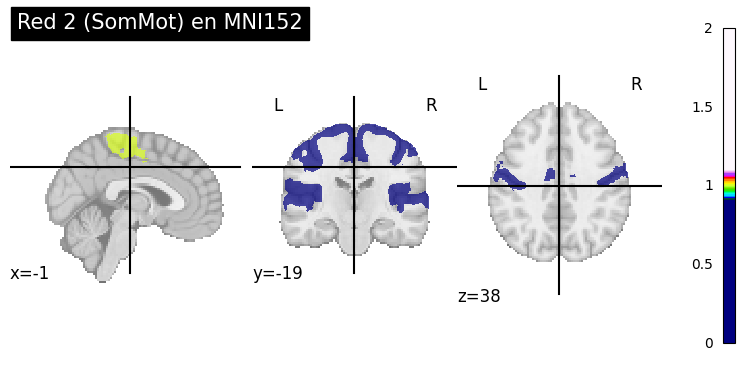

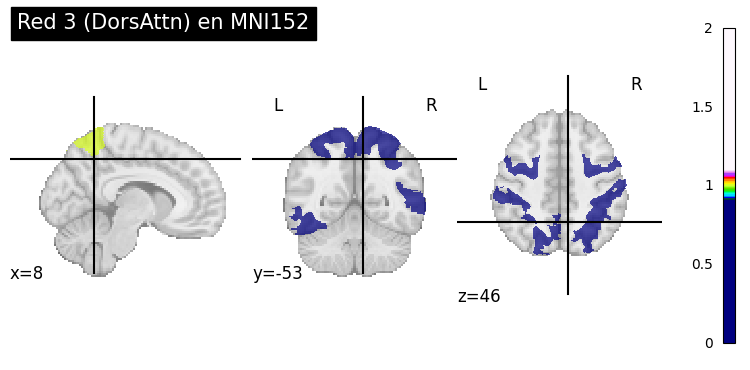

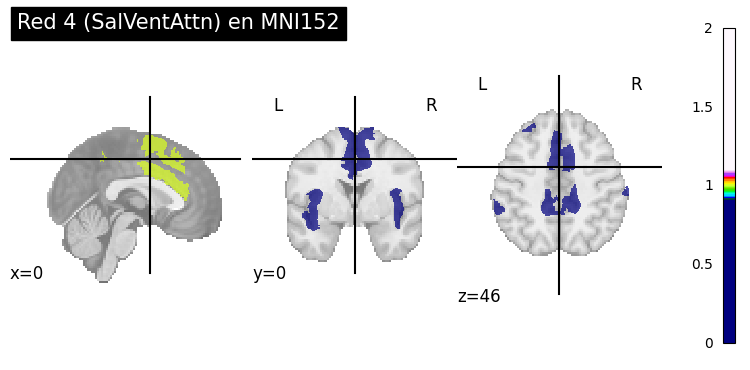

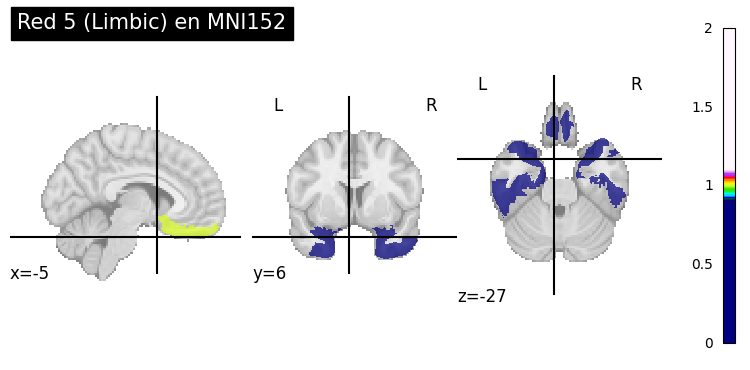

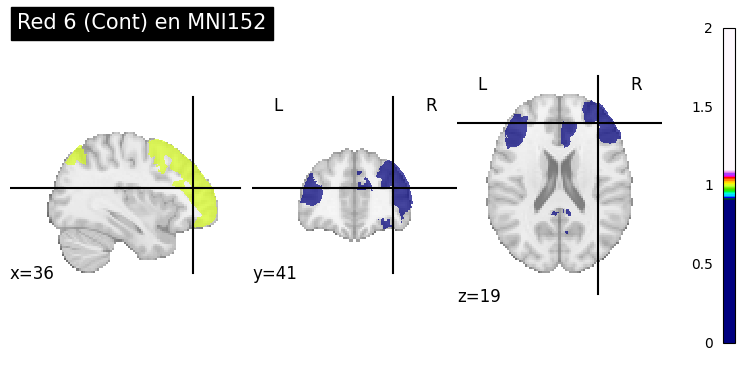

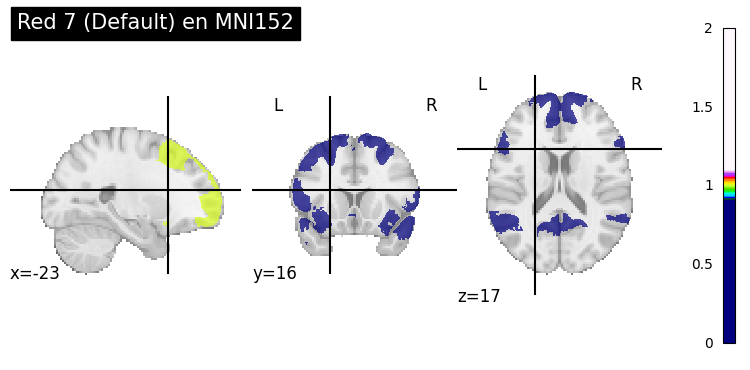

In [13]:
# Invertir el diccionario si no lo tienes ya
number_to_name = {v: k for k, v in net_name_to_number.items()}

# Plot de cada red
for net in range(1, 8):
    plotting.plot_roi(
        mask_imgs[net],
        title=f"Red {net} ({number_to_name[net]}) en MNI152"
    )
    plotting.show()

## Resamplear las 7 máscaras a MNI305 (espacio del fMRI)

El remuestreo con nearest preserva los valores enteros (0/1) y evita crear valores intermedios. Se observa que la máscara se adapta bien al volumen fMRI, aunque los bordes pueden perder algún voxel.




In [14]:
mask_imgs_resampled = {}
for net in range(1,8):
    mask_imgs_resampled[net] = resample_to_img(
        source_img=mask_imgs[net],
        target_img=img,
        interpolation="nearest"   # KNN: vecino más cercano
    )
print("Máscaras resampleadas a MNI305")

Máscaras resampleadas a MNI305


In [15]:
print("Vóxeles activos antes (MNI152) y después (MNI305) del resample:")
for net in range(1,8):
    antes = np.sum(masks[net])   # masks está en MNI152
    despues = np.sum(mask_imgs_resampled[net].get_fdata().astype(int))
    print(f"Red {net}: antes={antes}, después={despues}, cambio={despues/antes*100:.1f}%")

Vóxeles activos antes (MNI152) y después (MNI305) del resample:
Red 1: antes=181777, después=29464, cambio=16.2%
Red 2: antes=128983, después=66786, cambio=51.8%
Red 3: antes=159456, después=59601, cambio=37.4%
Red 4: antes=108704, después=74135, cambio=68.2%
Red 5: antes=92104, después=69431, cambio=75.4%
Red 6: antes=123444, después=75814, cambio=61.4%
Red 7: antes=261217, después=173524, cambio=66.4%


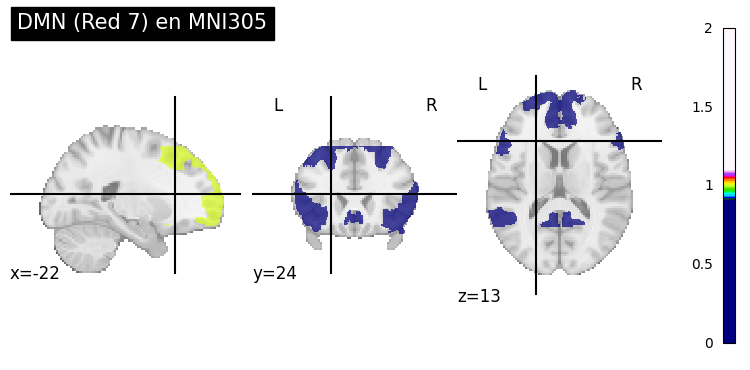

In [16]:
plotting.plot_roi(mask_imgs_resampled[7], title="DMN (Red 7) en MNI305")
plotting.show()

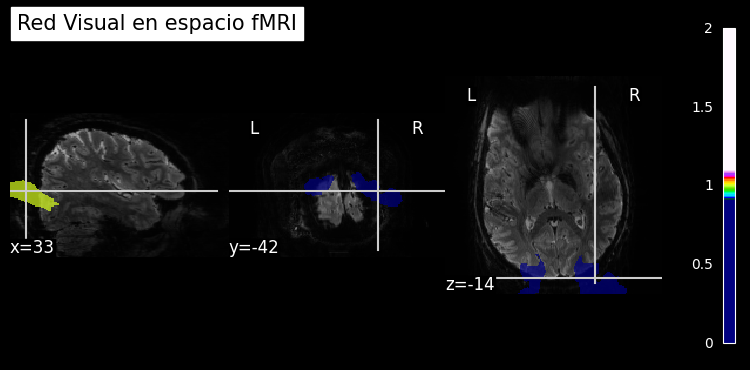

In [17]:
import numpy as np
from nilearn import plotting

# Calcular la media temporal del fMRI (imagen de fondo)
mean_fmri = np.mean(img.get_fdata(), axis=-1)
mean_img = nib.Nifti1Image(mean_fmri, img.affine)

# Superponer máscara de la red visual (red 1) sobre el cerebro promedio
plotting.plot_roi(mask_imgs_resampled[1], bg_img=mean_img, title="Red Visual en espacio fMRI")
plotting.show()

## Extraer señales de las 7 redes con filtrado (detrend, paso banda)

Se extrae la señal BOLD promedio para cada una de las 7 redes. Se aplica:

detrend=True para eliminar derivas lineales.

standardize=True (z-score) para que todas las redes sean comparables.

Filtro paso banda 0.01–0.1 Hz (elimina ruido fisiológico y derivas muy lentas).

Suavizado espacial de 6 mm FWHM para reducir ruido.
El resultado son 7 series temporales normalizadas.

Para visualizar el efecto del z-score, extraemos una red sin estandarizar

In [18]:
TR = 2.5
time_series_red = {}

for net in range(1, 8):
    masker = NiftiMasker(
        mask_img=mask_imgs_resampled[net],
        detrend=True,
        standardize='zscore_sample',   # evitar warning
        low_pass=0.1,
        high_pass=0.01,
        t_r=TR,
        # smoothing_fwhm=6,  # opcional, pero lo dejamos fuera por velocidad
        verbose=0
    )
    # Obtener matriz (tiempo, vóxeles)
    ts_voxels = masker.fit_transform(img)   # shape (256, n_voxels)
    # Promediar a lo largo de los vóxeles -> (256,)
    ts_mean = ts_voxels.mean(axis=1)
    time_series_red[net] = ts_mean

# Apilar las 7 series en una matriz (tiempo, 7)
time_series = np.column_stack([time_series_red[net] for net in range(1, 8)])
print("Shape señales (tiempo, redes):", time_series.shape)  # (256, 7)

C:\Users\Usuario\AppData\Local\Temp\ipykernel_25428\1125611654.py:16: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  ts_voxels = masker.fit_transform(img)   # shape (256, n_voxels)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_25428\1125611654.py:16: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  ts_voxels = masker.fit_transform(img)   # shape (256, n_voxels)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_25428\1125611654.py:16: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  ts_voxels = masker.fit_transform(img)   # shape (256, n_voxels)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_25428\1125611654.py:16: UserWarning: [NiftiMasker.fit] Generation of a mask has been

Shape señales (tiempo, redes): (256, 7)


In [23]:
print("Estadísticas de time_series (por red):")
print("Media:", time_series.mean(axis=0))
print("Desviación estándar:", time_series.std(axis=0))
print("Valor mínimo:", time_series.min(axis=0))
print("Valor máximo:", time_series.max(axis=0))

Estadísticas de time_series (por red):
Media: [ 5.8389560e-10  6.7848305e-10 -4.2200554e-10 -2.6084308e-09
 -6.2937033e-10  1.0404619e-09 -4.1109161e-10]
Desviación estándar: [0.074196   0.0690963  0.053866   0.0917457  0.0772433  0.09034858
 0.07415827]
Valor mínimo: [-0.32313514 -0.27973673 -0.26935065 -0.47922552 -0.3144624  -0.4315915
 -0.41274866]
Valor máximo: [0.19693309 0.16909556 0.14600441 0.26937255 0.23490213 0.29181647
 0.19505882]


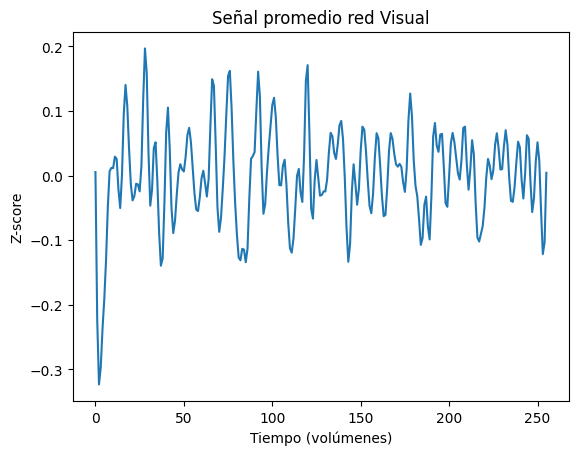

In [19]:
import matplotlib.pyplot as plt
plt.plot(time_series[:, 0])   # red 1 (Visual)
plt.title('Señal promedio red Visual')
plt.xlabel('Tiempo (volúmenes)')
plt.ylabel('Z-score')
plt.show()

## Gráfica: señal antes y después de z-score

Para visualizar el efecto del z-score, extraemos una red sin estandarizar.

C:\Users\Usuario\AppData\Local\Temp\ipykernel_25428\2907564150.py:3: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  ts_raw = masker_raw.fit_transform(img).flatten()


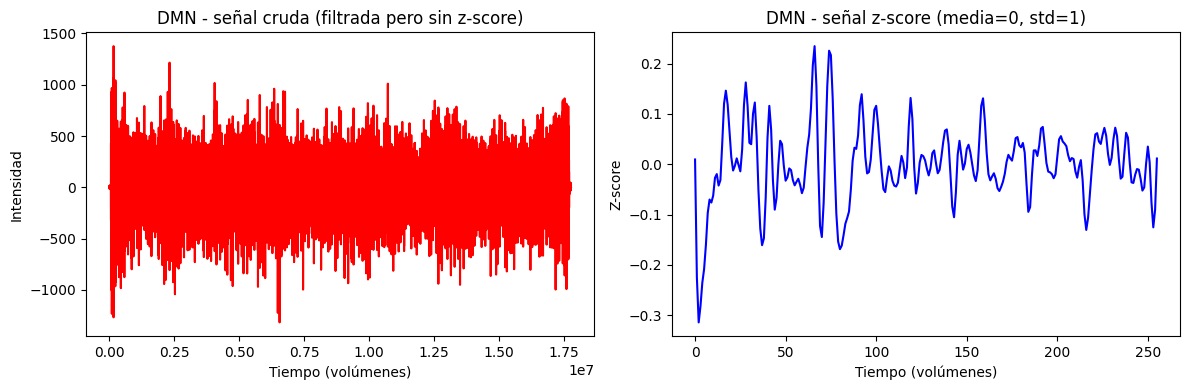

In [20]:
# Extraer señal de la red 5 (DMN) sin estandarizar
masker_raw = NiftiMasker(mask_img=mask_imgs_resampled[5], detrend=True, standardize=False, low_pass=0.1, high_pass=0.01, t_r=TR)
ts_raw = masker_raw.fit_transform(img).flatten()

# La señal ya estandarizada está en time_series[:,4] (red 5)
ts_norm = time_series[:,4]

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(ts_raw, color='red')
plt.title("DMN - señal cruda (filtrada pero sin z-score)")
plt.xlabel("Tiempo (volúmenes)")
plt.ylabel("Intensidad")
plt.subplot(1,2,2)
plt.plot(ts_norm, color='blue')
plt.title("DMN - señal z-score (media=0, std=1)")
plt.xlabel("Tiempo (volúmenes)")
plt.ylabel("Z-score")
plt.tight_layout()
plt.show()

La señal cruda tiene media distinta de cero y mayor variabilidad. Tras el z-score, ambas redes quedan en la misma escala, facilitando la comparación y la definición de un umbral común.

In [27]:
import pickle

# Guardar time_series (necesario para point process y modelado)
with open('time_series.pkl', 'wb') as f:
    pickle.dump(time_series, f)

# Opcional, pero recomendado si quieres evitar re-ejecutar el resample pesado:
with open('mask_imgs_resampled.pkl', 'wb') as f:
    pickle.dump(mask_imgs_resampled, f)

print("Variables guardadas correctamente en archivos .pkl")

Variables guardadas correctamente en archivos .pkl


In [29]:
# Normalizar cada columna (red) por separado
time_series_norm = (time_series - time_series.mean(axis=0)) / time_series.std(axis=0)

# Verificar que ahora la desviación es 1
print("Nueva desviación estándar por red:", time_series_norm.std(axis=0))
print("Nuevos máximos:", time_series_norm.max(axis=0))

Nueva desviación estándar por red: [0.99999976 0.99999994 1.0000001  1.0000001  0.99999994 0.99999994
 1.0000001 ]
Nuevos máximos: [2.6542277 2.4472446 2.7105117 2.9360783 3.041068  3.2298956 2.6303043]


## Point process (binarización con umbral de 1 SD)

Se define un evento (red activa) cuando su señal normalizada supera +1 desviación típica. Como la señal tiene media 0 y std 1, este umbral corresponde a activaciones fuertes (>1σ). El resultado es una secuencia binaria de 7 bits por cada instante.

In [31]:
threshold_sd = 1.0   # 1 desviación típica
binary_states = (time_series_norm > threshold_sd).astype(int)
print("Estados binarios shape:", binary_states.shape)  # (256, 7)

event_rates = binary_states.mean(axis=0)
for i, rate in enumerate(event_rates, 1):
    print(f"Red {i}: {rate*100:.1f}% de instantes activos")

Estados binarios shape: (256, 7)
Red 1: 12.1% de instantes activos
Red 2: 14.1% de instantes activos
Red 3: 10.9% de instantes activos
Red 4: 9.4% de instantes activos
Red 5: 10.9% de instantes activos
Red 6: 12.1% de instantes activos
Red 7: 9.4% de instantes activos


In [32]:
import pickle
with open('time_series_norm.pkl', 'wb') as f:
    pickle.dump(time_series_norm, f)
with open('binary_states.pkl', 'wb') as f:
    pickle.dump(binary_states, f)
print("Variables guardadas")

Variables guardadas


## Distribución de estados conjuntos (novedad)

Se calcula la frecuencia de cada uno de los 2^7 = 128 posibles patrones de activación. La distribución no es uniforme: algunos estados aparecen mucho más que otros, lo que indica que la actividad cerebral en reposo no es aleatoria y tiene una estructura preferente. Esto respalda la hipótesis de que existen patrones temporales no estocásticos.

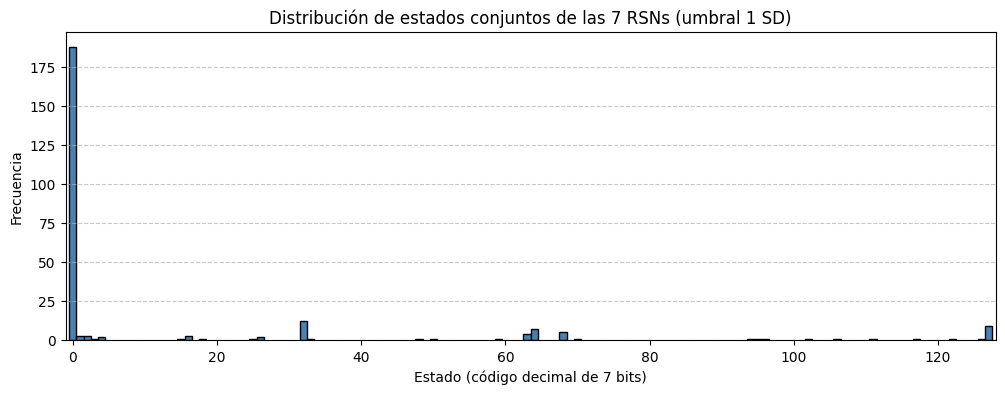

In [ ]:
# Convertir cada fila de 7 bits a un número 0..127
weights = 2**np.arange(6, -1, -1)  
state_codes = binary_states @ weights
unique, counts = np.unique(state_codes, return_counts=True)

# Histograma
import matplotlib.pyplot as plt
plt.figure(figsize=(12,4))
plt.bar(unique, counts, width=1.0, color='steelblue', edgecolor='black')
plt.xlabel("Estado (código decimal de 7 bits)")
plt.ylabel("Frecuencia")
plt.title("Distribución de estados conjuntos de las 7 RSNs (umbral 1 SD)")
plt.xlim(-1, 128)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Comparación del point process con distintos umbrales (0.5 SD / 1 SD / 1.5 SD / 2 SD)

Ejecutamos el point process y mostramos las gráficas para comparar


Tasas de activación (%) por red y umbral
Red          0.5 SD     1.0 SD     1.5 SD     2.0 SD
------------------------------------------------------------
Red 1       28.9    12.1     5.5     2.7
Red 2       32.8    14.1     5.1     2.0
Red 3       27.0    10.9     4.7     2.0
Red 4       25.4     9.4     4.3     2.0
Red 5       27.7    10.9     8.2     2.7
Red 6       27.7    12.1     5.1     2.7
Red 7       26.6     9.4     3.9     1.2

Eventos totales (sobre 256x7 = 1792 celdas):
  Umbral 0.5 SD: 3514 eventos
  Umbral 1.0 SD: 1414 eventos
  Umbral 1.5 SD: 658 eventos
  Umbral 2.0 SD: 273 eventos


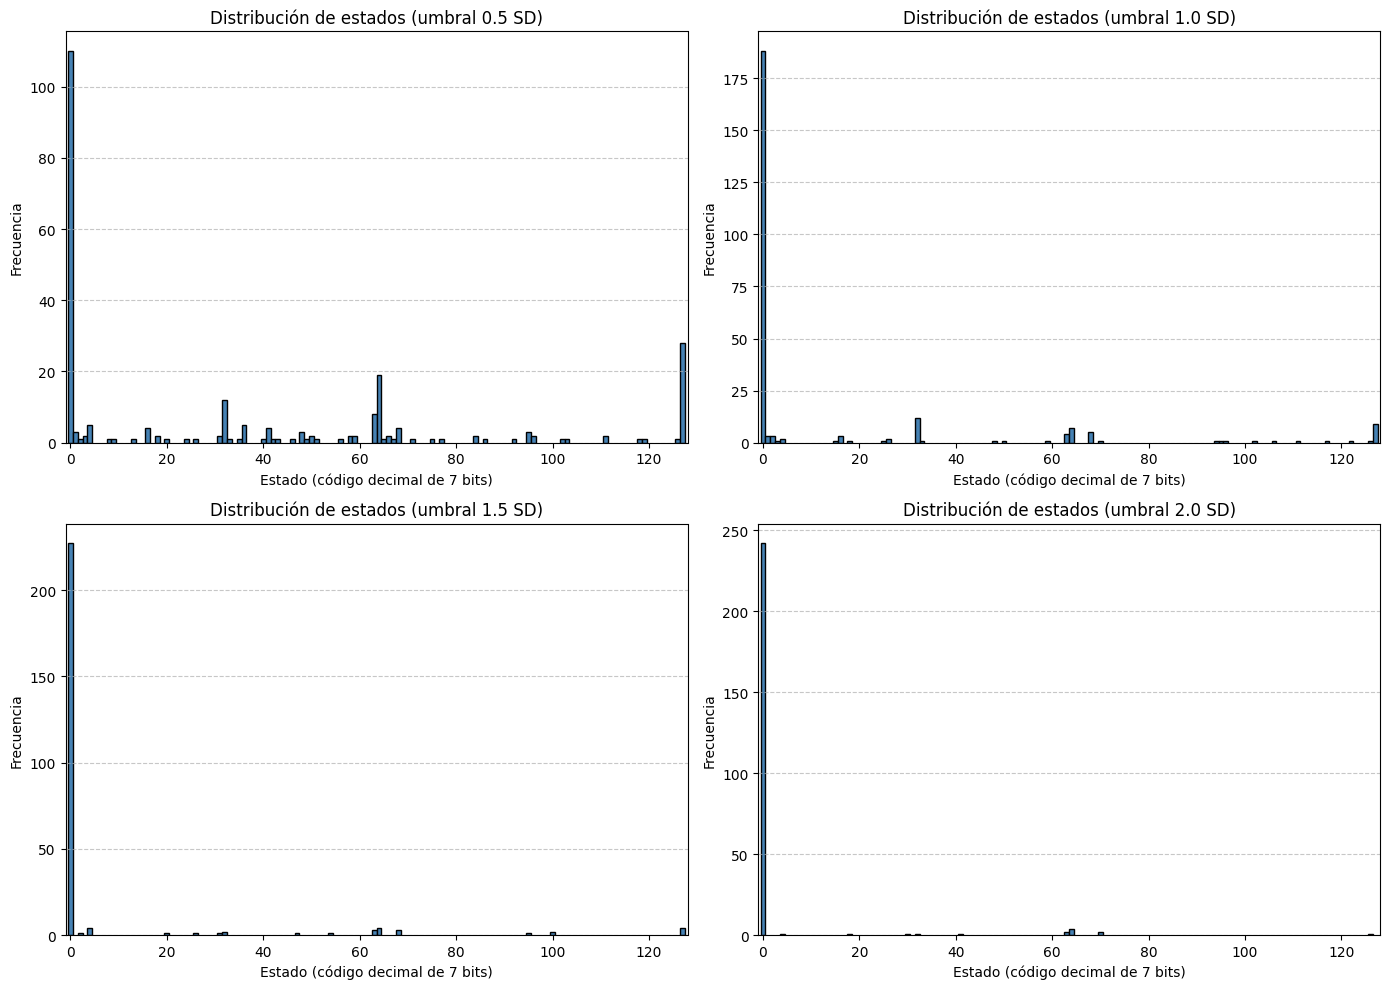

In [40]:
import numpy as np
import matplotlib.pyplot as plt

# Umbrales a probar
umbrales = [0.5, 1.0, 1.5, 2.0]

# Inicializar matriz para almacenar tasas: filas=redes (1..7), columnas=umbrales
tasas = np.zeros((7, len(umbrales)))

# Calcular tasas por red y umbral
for j, th in enumerate(umbrales):
    binary = (time_series_norm > th).astype(int)
    tasas[:, j] = binary.mean(axis=0) * 100   # porcentaje

# --- Imprimir tabla bonita ---
print("\n" + "="*60)
print("Tasas de activación (%) por red y umbral")
print("="*60)
# Cabecera
print(f"{'Red':<8}", end="")
for th in umbrales:
    print(f"{th:>8} SD", end="")
print()
print("-"*60)
# Filas
for i in range(7):
    print(f"Red {i+1:<4}", end="")
    for j in range(len(umbrales)):
        print(f"{tasas[i, j]:>8.1f}", end="")
    print()
print("="*60)

# También imprimir total de eventos (opcional)
print("\nEventos totales (sobre 256x7 = 1792 celdas):")
for j, th in enumerate(umbrales):
    n_eventos = int((tasas[:, j].sum() / 100) * 1792)  # aproximado
    print(f"  Umbral {th} SD: {n_eventos} eventos")

# --- Gráficas de distribución (igual que antes) ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, th in enumerate(umbrales):
    binary = (time_series_norm > th).astype(int)
    weights = 2**np.arange(6, -1, -1)
    state_codes = binary @ weights
    unique, counts = np.unique(state_codes, return_counts=True)
    
    ax = axes[idx]
    ax.bar(unique, counts, width=1.0, color='steelblue', edgecolor='black')
    ax.set_xlabel("Estado (código decimal de 7 bits)")
    ax.set_ylabel("Frecuencia")
    ax.set_title(f"Distribución de estados (umbral {th} SD)")
    ax.set_xlim(-1, 128)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## Preparación del dataset temporal y modelo predictivo (igual que Notebook1 pero con 7 redes)

Se repite el mismo análisis predictivo que en el Notebook1, pero ahora con 7 estados binarios (uno por red) y con el point process corregido. La evaluación en test (futuro no visto) permite valorar si la estructura temporal detectada es generalizable.

In [42]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

umbrales = [0.5, 1.0, 1.5, 2.0]
resultados = []

for th in umbrales:
    # 1. Generar estados binarios
    binary = (time_series_norm > th).astype(int)
    
    # 2. Preparar dataset temporal
    X = binary[:-1]
    y = binary[1:]
    split = int(0.8 * len(X))
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]
    
    # 3. Entrenar y predecir (1 modelo por red)
    y_pred_test = np.zeros_like(y_test)
    for i in range(7):
        model = LogisticRegression(max_iter=1000, class_weight='balanced')  # añadimos balanced para ayudar con desbalanceo
        model.fit(X_train, y_train[:, i])
        y_pred_test[:, i] = model.predict(X_test)
    
    # 4. Métricas
    acc = accuracy_score(y_test.flatten(), y_pred_test.flatten())
    f1 = f1_score(y_test.flatten(), y_pred_test.flatten())
    
    # 5. Baseline (persistencia)
    baseline_pred = X_test
    acc_baseline = accuracy_score(y_test.flatten(), baseline_pred.flatten())
    
    # 6. Conteo de eventos (1's) en test (para diagnosticar desbalanceo)
    n_eventos_test = np.sum(y_test)
    total_celdas_test = y_test.size
    porcentaje_eventos = 100 * n_eventos_test / total_celdas_test
    
    resultados.append({
        'Umbral (SD)': th,
        'Accuracy': acc,
        'F1-score': f1,
        'Baseline Acc': acc_baseline,
        '% Eventos (test)': porcentaje_eventos,
        'Eventos/test': f"{n_eventos_test}/{total_celdas_test}"
    })

# Mostrar tabla
df = pd.DataFrame(resultados)
print("\n=== COMPARACIÓN DE MODELOS PREDICTIVOS ===\n")
print(df.to_string(index=False))


=== COMPARACIÓN DE MODELOS PREDICTIVOS ===

 Umbral (SD)  Accuracy  F1-score  Baseline Acc  % Eventos (test) Eventos/test
         0.5  0.840336  0.677966      0.865546         21.848739       78/357
         1.0  0.873950  0.210526      0.946779          3.921569       14/357
         1.5  1.000000  0.000000      1.000000          0.000000        0/357
         2.0  1.000000  0.000000      1.000000          0.000000        0/357


c:\Users\Usuario\Desktop\UNIVERSIDAD\MÁSTER\TFM\Code\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Usuario\Desktop\UNIVERSIDAD\MÁSTER\TFM\Code\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [43]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

umbrales = [0.5, 1.0, 1.5, 2.0]
resultados_cambios = []

for th in umbrales:
    # 1. Estados binarios con el umbral dado
    binary = (time_series_norm > th).astype(int)
    
    # 2. Matriz de cambios: 1 si hubo cambio (0→1 o 1→0) entre t y t+1
    changes = (binary[1:] != binary[:-1]).astype(int)
    
    # 3. Para predecir el cambio en t+1 usamos el estado en t (como input)
    X = binary[:-1]          # estado en t
    y = changes              # qué redes cambiarán en t+1
    
    split = int(0.8 * len(X))
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]
    
    # 4. Entrenar un modelo por red (logistic regression)
    y_pred_test = np.zeros_like(y_test)
    for i in range(7):
        model = LogisticRegression(max_iter=1000, class_weight='balanced')
        model.fit(X_train, y_train[:, i])
        y_pred_test[:, i] = model.predict(X_test)
    
    # 5. Métricas
    acc = accuracy_score(y_test.flatten(), y_pred_test.flatten())
    f1 = f1_score(y_test.flatten(), y_pred_test.flatten())
    
    # 6. Baseline trivial: predecir que nunca hay cambio
    baseline_pred = np.zeros_like(y_test)
    acc_baseline = accuracy_score(y_test.flatten(), baseline_pred.flatten())
    
    # 7. Porcentaje de cambios en test
    pct_cambios = y_test.mean() * 100  # sobre todas las celdas (7*len(test))
    
    resultados_cambios.append({
        'Umbral (SD)': th,
        'Accuracy': acc,
        'F1-score': f1,
        'Baseline Acc': acc_baseline,
        '% Cambios (test)': pct_cambios
    })

# Mostrar tabla
df_cambios = pd.DataFrame(resultados_cambios)
print("\n=== PREDICCIÓN DE CAMBIOS (transiciones) ===\n")
print(df_cambios.to_string(index=False))


=== PREDICCIÓN DE CAMBIOS (transiciones) ===

 Umbral (SD)  Accuracy  F1-score  Baseline Acc  % Cambios (test)
         0.5  0.689076  0.335329      0.865546         13.445378
         1.0  0.915966  0.444444      0.946779          5.322129
         1.5  1.000000  0.000000      1.000000          0.000000
         2.0  1.000000  0.000000      1.000000          0.000000


c:\Users\Usuario\Desktop\UNIVERSIDAD\MÁSTER\TFM\Code\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Usuario\Desktop\UNIVERSIDAD\MÁSTER\TFM\Code\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
